In [25]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [15]:
dataset_path = '/kaggle/input/datasets/orvile/bccd-blood-cell-count-and-detection-dataset' 
train_dir = os.path.join(dataset_path, 'train')
test_dir = os.path.join(dataset_path, 'test')
val_dir = os.path.join(dataset_path, 'val')

Sample path: /kaggle/input/datasets/orvile/bccd-blood-cell-count-and-detection-dataset/train/img/BloodImage_00001.jpeg


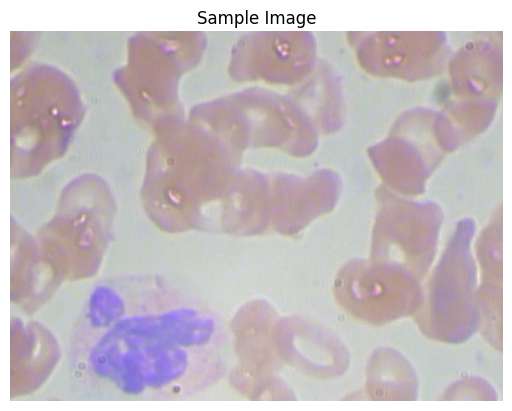

In [18]:
sample_img = os.path.join(dataset_path, 'train', 'img', 'BloodImage_00001.jpeg')
print(f'Sample path: {sample_img}')

sample_bgr = cv2.imread(sample_img)
sample_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Hiển thị ảnh
plt.title('Sample Image')
plt.imshow(sample_rgb)
plt.axis('off')
plt.show()

In [35]:
def preprocess_rbc(image_path, debug=True):
    denoise = cv2.bilateralFilter(
    img_rgb,
    d=7,
    sigmaColor=50,
    sigmaSpace=50
    )
    
    # =========================
    # 2. LAB Color Space
    # =========================
    # RBC thường nổi bật mạnh ở A-channel
    # vì A biểu diễn Green <-> Red
    
    lab = cv2.cvtColor(denoise, cv2.COLOR_RGB2LAB)
    L, A, B = cv2.split(lab)
    
    # =========================
    # 3. CLAHE trên A-channel
    # =========================
    # Tăng contrast riêng cho RBC
    
    clahe = cv2.createCLAHE(
        clipLimit=1.5,
        tileGridSize=(8, 8)
    )
    
    A_clahe = clahe.apply(A)
    
    # =========================
    # 4. Median Blur
    # =========================
    # Median tốt cho salt-pepper/noise nhỏ
    # và giữ contour RBC tốt hơn Gaussian
    
    blur = cv2.medianBlur(A_clahe, 3)
    
    # =========================
    # 5. Otsu Threshold
    # =========================
    # RBC sáng hơn nền trên A-channel
    
    _, otsu = cv2.threshold(
        blur,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    
    # =========================
    # 6. Morphology
    # =========================
    
    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (3, 3)
    )
    
    # Remove small noise
    opening = cv2.morphologyEx(
        otsu,
        cv2.MORPH_OPEN,
        kernel,
        iterations=1
    )
    
    # Fill small holes in RBC
    clean = cv2.morphologyEx(
        opening,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=1
    )
    
    # =========================
    # 7. Optional: Sure Background
    # =========================
    # Hữu ích cho Watershed
    
    sure_bg = cv2.dilate(
        clean,
        kernel,
        iterations=2
    )
    
    # =========================
    # 8. Distance Transform
    # =========================
    # Tìm center từng RBC
    
    dist = cv2.distanceTransform(
        clean,
        cv2.DIST_L2,
        5
    )
    
    # Normalize để visualize đẹp hơn
    
    dist_norm = cv2.normalize(
        dist,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    ).astype(np.uint8)
    
    # =========================
    # 9. Sure Foreground
    # =========================
    # Peak của từng RBC
    
    _, sure_fg = cv2.threshold(
        dist,
        0.25 * dist.max(),
        255,
        0
    )
    
    sure_fg = np.uint8(sure_fg)
    
    # =========================
    # 10. Unknown Region
    # =========================
    
    unknown = cv2.subtract(
        sure_bg,
        sure_fg
    )

    
    # =========================
    # Show kết quả
    # =========================
    if debug:
    
        titles = [
            "Original",
            "Denoise",
            "A Channel",
            "CLAHE",
            "Blur",
            "Otsu",
            "Opening",
            "Clean",
            "Sure BG",
            "Distance Transform",
            "Sure FG",
            "Unknown"
        ]
        
        images = [
            img_rgb,
            denoise,
            A,
            A_clahe,
            blur,
            otsu,
            opening,
            clean,
            sure_bg,
            dist_norm,
            sure_fg,
            unknown
        ]
    
        plt.figure(figsize=(18, 10))
    
        for i in range(len(images)):
            plt.subplot(3, 4, i + 1)
    
            if len(images[i].shape) == 2:
                plt.imshow(images[i], cmap='gray')
            else:
                plt.imshow(images[i])
    
            plt.title(titles[i])
            plt.axis('off')
    
        plt.tight_layout()
        plt.show()
    
    return {
        "denoise": denoise,
        "A_channel": A,
        "A_clahe": A_clahe,
        "blur": blur,
        "otsu": otsu,
        "opening": opening,
        "clean": clean,
        "sure_bg": sure_bg,
        "distance_transform": dist_norm,
        "sure_fg": sure_fg,
        "unknown": unknown
    }

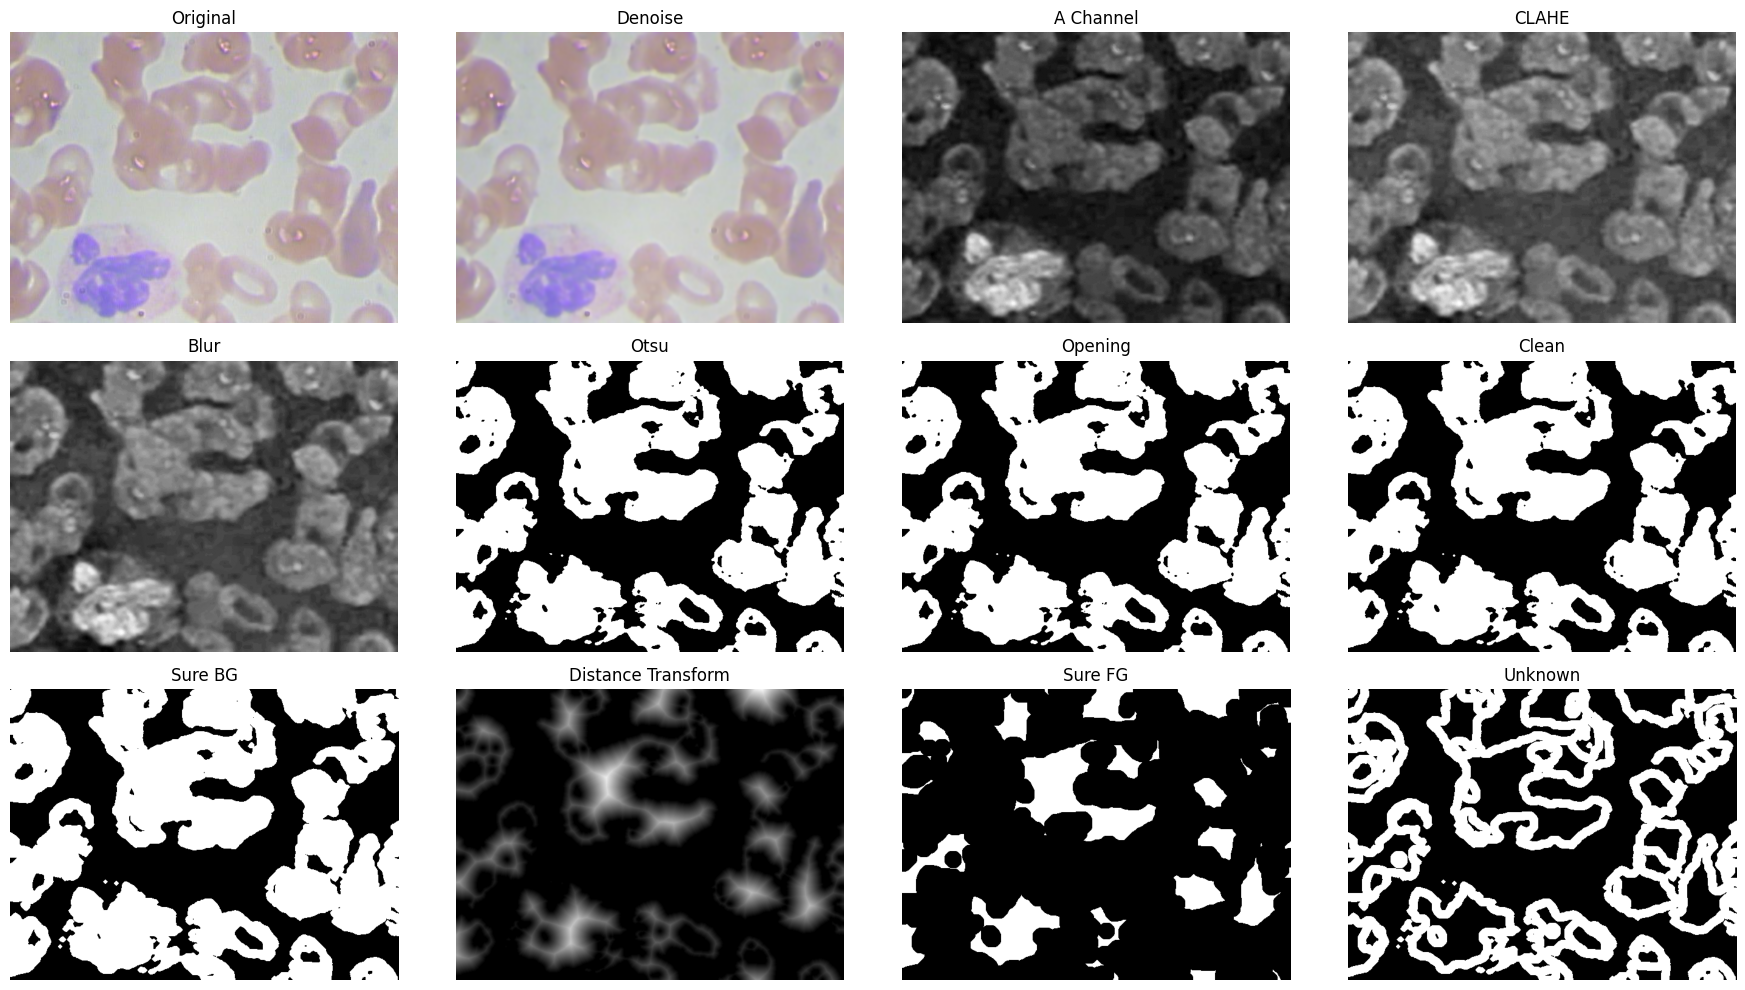

In [36]:
results = preprocess_rbc(sample_img)